##### Using survivalpredict's pipeline to interface with the sklearn ecosystem.

Survivalpredict's  `SklearnSurvivalPipeline` class allows us to interface directly with scikit-learn's greater ecosystem. There is a whole ecosystem centered around hyperparameter tuning, feature selection, and scaling out compute for scikit-learn compatible code that we can interface with. 

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import itertools
import pandas as pd

from sklearn.model_selection import GridSearchCV , cross_val_score
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from mlxtend.feature_selection import SequentialFeatureSelector
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

from survivalpredict.estimators import  CoxProportionalHazard,KaplanMeierSurvivalEstimator
from survivalpredict.metrics import integrated_brier_score_administrative_sklearn_scorer 
from survivalpredict.pipeline import SklearnSurvivalPipeline,build_sklearn_pipeline_target,make_sklearn_survival_pipeline
from survivalpredict.strata_preprocessing import StrataBuilderEncoder, StrataColumnTransformer, make_strata_column_transformer

from SurvSet.data import SurvLoader
loader = SurvLoader()

Let's start by loading in the data, using `SurvSet`. Notice that we are keeping the data as a dataframe. This allows us to retain feature names, enabling us to call out specific strata feature names when tuning for the best-performing strata.

In [2]:
df = loader.load_dataset("support2")["df"]
df = df.dropna()

times = df["time"].to_numpy().astype(np.int64)
events = df["event"].to_numpy().astype(np.bool_)
X_df = df[list(set(df.columns).difference(set(("pid", "event", "time"))))]

Next, we are going to determine the maximum point in time to observe for evaluating the model. As time goes forward, a smaller and smaller percentage of individuals will still be in the study, including the tail-end points in the 'integrated Brier score, which will artificially inflate the score, not highlighting improvements in performance in points in time that include most individuals.

In [3]:
max_time = np.percentile(times, 85).round().astype(np.int64)

The 'build_sklearn_pipeline_target' function allows us to take non-feature vectors, like `times`, `events`, `times_start`(for left censoring), and predetermined `strata` into a single vector that can be passed into scikit-learn classes.  The output of 'build_sklearn_pipeline_target'  will function as the 'y' vector for the SklearnSurvivalPipeline class.

Next, we will build a pipeline that will turn 'fac_sex', 'fac_income' columns into the strata, then preprocess the rest of the features, and finally train a Cox model.

In [4]:
y = build_sklearn_pipeline_target(times, events)

strata_transformers = make_strata_column_transformer(
    (StrataBuilderEncoder(), ["fac_sex", "fac_income"])
)

column_transformers = make_column_transformer(
    (StandardScaler(), make_column_selector(dtype_include=np.number)),
    (OneHotEncoder(), make_column_selector(dtype_include=[object, "string"])),
)

pipeline_cox = make_sklearn_survival_pipeline(
    strata_transformers,
    column_transformers,
    CoxProportionalHazard(),
    max_time=max_time,
)

In [5]:
pipeline_cox

,steps,"[('stratacolumntransformer', ...), ('columntransformer', ...), ...]"
,max_time,818
,memory,None
,strata_transformers,"[('stratabuilderencoder', ...)]"
,stratabuilderencoder__columns,"['fac_sex', 'fac_income']"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...), ('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False


We can now use sk's native cross_val_score, but we will need to pass in our own scorer

In [6]:
cross_val_score(
    pipeline_cox,
    X_df,
    y,
    scoring=integrated_brier_score_administrative_sklearn_scorer,
    error_score='raise',
).mean()

np.float64(-155.14165982224978)

In [7]:
#we can also build a cox model without strata

cross_val_score(
    make_sklearn_survival_pipeline(
        column_transformers,
        CoxProportionalHazard(),
        max_time=max_time,
    ),
    X_df,
    y,
    scoring=integrated_brier_score_administrative_sklearn_scorer,
).mean()

np.float64(-155.57987707062597)

Next, let compare this score agaist our KaplanMeier baseline.

In [8]:
cross_val_score(
    make_sklearn_survival_pipeline(column_transformers,KaplanMeierSurvivalEstimator(),max_time=max_time),
    X_df,
    y,
    scoring=integrated_brier_score_administrative_sklearn_scorer,
).mean()

np.float64(-179.90976086220107)

It looks like our first Cox models are not bad, we are perfoming better than KaplanMeier. We can now start hyperparameters and strata tuning.

In [9]:
#getting combinations of all categorical data

cat_cols = X_df.select_dtypes(pd.CategoricalDtype()).columns

#in case we wana look at strata combinations
cat_col_combinations = list(
    itertools.chain.from_iterable(
        itertools.combinations(cat_cols, i) for i in range(1, 3)
    )
)

#, this make gridseah run faster
#cat_col_combinations = cat_cols 


In [10]:
#you can take a look at all pram names and prameters with pipeline_cox.get_params()

pram_grid = {
    "stratacolumntransformer__stratabuilderencoder__columns": cat_col_combinations,
    "coxproportionalhazard__alpha": [0, 10, 100],
    "coxproportionalhazard__l1_ratio": [0.0, 0.25, 0.5, 0.75, 0.1],
}

In [11]:
#running the sklearn native GridSearchCV, you can replace GridSearchCV with your favorite hyperprameter tunning class
gs = GridSearchCV(
    pipeline_cox,
    pram_grid,
    scoring=integrated_brier_score_administrative_sklearn_scorer,
    n_jobs=5
)



In [12]:
#not all strata will be present in each cv split, this will cause error/warnings; this should not be an issue, as sparse strata are not a good strata regardless
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    gs.fit(X_df, y)

In [13]:
cv_results = pd.DataFrame(gs.cv_results_)

In [14]:
cv_results.sort_values('rank_test_score').head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_coxproportionalhazard__alpha,param_coxproportionalhazard__l1_ratio,param_stratacolumntransformer__stratabuilderencoder__columns,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
581,0.078644,0.020877,0.025802,0.003139,10,0.75,"(fac_sex, fac_sfdm2)","{'coxproportionalhazard__alpha': 10, 'coxpropo...",-115.303130,-130.309105,-109.784741,-113.272749,-117.771501,-117.288245,7.016321,1
647,0.090146,0.010091,0.021001,0.002417,10,0.10,"(fac_sex, fac_sfdm2)","{'coxproportionalhazard__alpha': 10, 'coxpropo...",-117.569822,-129.567804,-114.054706,-119.185414,-116.626711,-119.400891,5.348703,2
536,0.068624,0.011208,0.025103,0.006017,10,0.75,"(fac_sfdm2,)","{'coxproportionalhazard__alpha': 10, 'coxpropo...",-120.974142,-134.361984,-115.944527,-112.685033,-116.033203,-119.999778,7.653844,3
470,0.044824,0.002943,0.021780,0.001531,10,0.50,"(fac_sfdm2,)","{'coxproportionalhazard__alpha': 10, 'coxpropo...",-120.262328,-135.878106,-115.782033,-114.449942,-113.658374,-120.006156,8.258250,4
53,0.102290,0.008079,0.032066,0.003819,0,0.00,"(fac_sex, fac_sfdm2)","{'coxproportionalhazard__alpha': 0, 'coxpropor...",-118.260043,-127.720823,-114.920850,-124.128884,-115.504766,-120.107073,5.012660,5


In [15]:
#the 'best' parameters.
cv_results[cv_results['rank_test_score'] == 1]['params'].values[0]

{'coxproportionalhazard__alpha': 10,
 'coxproportionalhazard__l1_ratio': 0.75,
 'stratacolumntransformer__stratabuilderencoder__columns': ('fac_sex',
  'fac_sfdm2')}

In [16]:
strata_transformers = make_strata_column_transformer(
    (StrataBuilderEncoder(), ('fac_sfdm2', 'fac_sex'))
)

sp_pipeline_cox = make_sklearn_survival_pipeline(
    strata_transformers,
    column_transformers,
    CoxProportionalHazard(alpha=10, l1_ratio=0.75),
    max_time=max_time,
)

after tuning, we get a far better performing model.

In [17]:
cross_val_score(
    sp_pipeline_cox,
    X_df,
    y,
    scoring=integrated_brier_score_administrative_sklearn_scorer,
).mean()

np.float64(-117.28824506105533)

We are now going to experiment with feature selection.

In [18]:
X_np = column_transformers.fit_transform(X_df)

In [19]:
pipeline_cox2 = make_sklearn_survival_pipeline(
    CoxProportionalHazard(),
    max_time=max_time,
)

In [20]:
sfs = SequentialFeatureSelector(pipeline_cox2, 
                          k_features= 1, 
                          forward=False,  
                          scoring=integrated_brier_score_administrative_sklearn_scorer, 
                          cv=5, 
                          n_jobs=5)

In [21]:
sfs.fit(X_np,y)

,estimator,SklearnSurviv...nalHazard())])
,k_features,"(1, ...)"
,forward,False
,floating,False
,verbose,0
,scoring,make_scorer(i...hod='predict')
,cv,5
,n_jobs,5
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


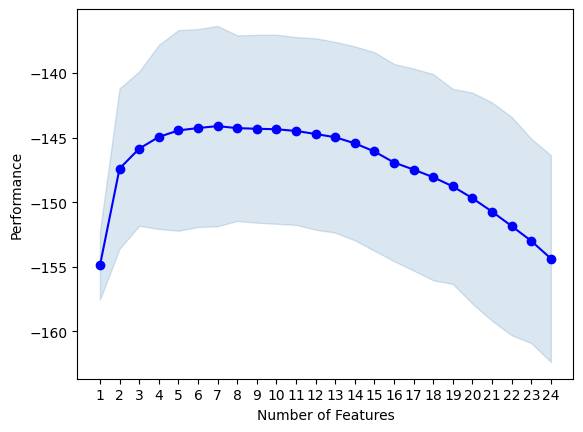

In [22]:
fig = plot_sfs(sfs.get_metric_dict(), kind='std_err')


In [23]:
step_wise_feature_selection_results = pd.DataFrame.from_records(sfs.subsets_).T

In [24]:
step_wise_feature_selection_results.sort_values('avg_score',ascending=False).head(5)

,feature_idx,cv_scores,avg_score,feature_names
7,"(1, 2, 7, 11, 15, 16, 21)","[-143.566677821797, -136.2559405565069, -159.1...",-144.112512,"(1, 2, 7, 11, 15, 16, 21)"
6,"(1, 7, 11, 15, 16, 21)","[-143.83516942714164, -135.87268885869486, -15...",-144.263809,"(1, 7, 11, 15, 16, 21)"
8,"(0, 1, 2, 7, 11, 15, 16, 21)","[-141.46966297859967, -138.35774779284924, -15...",-144.270329,"(0, 1, 2, 7, 11, 15, 16, 21)"
9,"(0, 1, 2, 7, 11, 12, 15, 16, 21)","[-149.19738821435038, -135.5058462894316, -155...",-144.318642,"(0, 1, 2, 7, 11, 12, 15, 16, 21)"
10,"(0, 1, 2, 6, 7, 11, 12, 15, 16, 21)","[-149.00292841678186, -134.64053897377696, -15...",-144.356467,"(0, 1, 2, 6, 7, 11, 12, 15, 16, 21)"


In [25]:
best_features_idxs = list(step_wise_feature_selection_results.iloc[7]['feature_idx'])                 

In [26]:
best_fearures_names = column_transformers.get_feature_names_out()[list(best_features_idxs)]
best_fearures_names

array(['standardscaler__num_surv2m', 'standardscaler__num_hrt',
       'standardscaler__num_adlp', 'standardscaler__num_scoma',
       'standardscaler__num_num_co', 'standardscaler__num_adls',
       'standardscaler__num_sps', 'standardscaler__num_surv6m'],
      dtype=object)

In [27]:
cross_val_score(
    pipeline_cox2,
    X_np[:,best_features_idxs],
    y,
    scoring=integrated_brier_score_administrative_sklearn_scorer,
).mean()

np.float64(-144.27032908030452)

In [28]:
best_features_col_names = [i.split('__')[1] for i in column_transformers.get_feature_names_out()[list(best_features_idxs)]]
strat_cols = ['fac_sfdm2', 'fac_sex']
cols = best_features_col_names + strat_cols

In [29]:

X_df2 = X_df[cols]


strata_transformers = make_strata_column_transformer(
    (StrataBuilderEncoder(), strat_cols)
)

column_transformers = make_column_transformer(
    (StandardScaler(), best_features_col_names ),
)

pipeline_cox3 = make_sklearn_survival_pipeline(
    strata_transformers,
    column_transformers,
    CoxProportionalHazard(),
    max_time=max_time,
)

Using both the best strata and best features, we are able to get the best performing model so far.

In [30]:
cross_val_score(
    pipeline_cox3,
    X_df2,
    y,
    scoring=integrated_brier_score_administrative_sklearn_scorer,
).mean()

np.float64(-112.16788210122328)